# 08 Spatial: Position, Rotation, Pose

Spatial wrappers declare physical meaning beyond array shape: positions, rotations, and rigid poses each have specific operations.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tal.core import ParamEvalOptions
from tal.spatial import Pose
from tal.spatial.temporal.options import RotationTemporalOptions

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: typed spatial objects

The helper returns a `Position`, `Rotation`, and `Pose` sharing one sequence layout.


In [2]:
pos, rot, pose = make_pose_demo_objects()

display_result(
    'Spatial inputs',
    pd.DataFrame(
        [
            {'object': 'Position', 'dims': dict(pos.unsafe_data.sizes), 'vars': list(pos.unsafe_data.data_vars)},
            {'object': 'Rotation', 'dims': dict(rot.unsafe_data.sizes), 'vars': list(rot.unsafe_data.data_vars)},
            {'object': 'Pose', 'dims': dict(pose.unsafe_data.sizes), 'vars': list(pose.unsafe_data.data_vars)},
        ]
    ),
)


#### Spatial inputs

,object,dims,vars
0,Position,"{'sample': 3, 'axis': 3}",[position]
1,Rotation,"{'sample': 3, 'quat': 4}",[rotation]
2,Pose,"{'sample': 3, 'axis': 3, 'quat': 4}","[position, rotation]"


,object,dims,vars
0,Position,"{'sample': 3, 'axis': 3}",[position]
1,Rotation,"{'sample': 3, 'quat': 4}",[rotation]
2,Pose,"{'sample': 3, 'axis': 3, 'quat': 4}","[position, rotation]"


## Representation conversion

Rotations and poses can be represented in multiple storage forms. Conversion should preserve trajectory dimensions and semantics.


In [3]:
rot_m = rot.as_matrix(validate=True)
rot_q = rot_m.as_quat(validate=True)
pose_m = pose.as_matrix(validate=True)
pose_back = Pose.from_matrix(pose_m, validate=True)

display_result(
    'Representation conversions',
    pd.DataFrame(
        [
            {'result': 'rotation.as_matrix()', 'type': type(rot_m).__name__, 'dims': dict(rot_m.unsafe_data.sizes)},
            {'result': 'matrix.as_quat()', 'type': type(rot_q).__name__, 'dims': dict(rot_q.unsafe_data.sizes)},
            {'result': 'pose.as_matrix()', 'type': type(pose_m).__name__, 'dims': dict(pose_m.unsafe_data.sizes)},
            {'result': 'Pose.from_matrix()', 'type': type(pose_back).__name__, 'dims': dict(pose_back.unsafe_data.sizes)},
        ]
    ),
)


#### Representation conversions

,result,type,dims
0,rotation.as_matrix(),Rotation,"{'sample': 3, 'row': 3, 'col': 3}"
1,matrix.as_quat(),Rotation,"{'sample': 3, 'quat': 4}"
2,pose.as_matrix(),Pose,"{'sample': 3, 'row': 4, 'col': 4}"
3,Pose.from_matrix(),Pose,"{'sample': 3, 'row': 4, 'col': 4}"


,result,type,dims
0,rotation.as_matrix(),Rotation,"{'sample': 3, 'row': 3, 'col': 3}"
1,matrix.as_quat(),Rotation,"{'sample': 3, 'quat': 4}"
2,pose.as_matrix(),Pose,"{'sample': 3, 'row': 4, 'col': 4}"
3,Pose.from_matrix(),Pose,"{'sample': 3, 'row': 4, 'col': 4}"


## Composition, inverse, apply, and interpolation

These are spatial operations, not generic array operations. The result should remain typed and role-aware.


In [4]:
pose_identity = pose.compose(pose.inverse(), validate=True)
pose_identity_matrix = pose_identity.as_matrix(validate=True)
moved = pose.apply(pos, validate=True)
rot_mid = rot.param.at(
    [0.25, 0.75],
    on='time_s',
    opts=RotationTemporalOptions(method='slerp'),
)
pos_mid = pos.param.at([0.25, 0.75], on='time_s', opts=ParamEvalOptions(method='linear'))

display_result(
    'Pose operations and param evaluation',
    pd.DataFrame(
        [
            {'result': 'pose.compose(pose.inverse())', 'type': type(pose_identity_matrix).__name__, 'dims': dict(pose_identity_matrix.unsafe_data.sizes)},
            {'result': 'pose.apply(position)', 'type': type(moved).__name__, 'dims': dict(moved.unsafe_data.sizes)},
            {'result': 'rotation.param.at(slerp)', 'type': type(rot_mid).__name__, 'dims': dict(rot_mid.unsafe_data.sizes)},
            {'result': 'position.param.at(linear)', 'type': type(pos_mid).__name__, 'dims': dict(pos_mid.unsafe_data.sizes)},
        ]
    ),
)


#### Pose operations and param evaluation

,result,type,dims
0,pose.compose(pose.inverse()),Pose,"{'sample': 3, 'row': 4, 'col': 4}"
1,pose.apply(position),Position,"{'sample': 3, 'axis': 3}"
2,rotation.param.at(slerp),Rotation,"{'quat': 4, 'sample': 2}"
3,position.param.at(linear),Position,"{'axis': 3, 'sample': 2}"


,result,type,dims
0,pose.compose(pose.inverse()),Pose,"{'sample': 3, 'row': 4, 'col': 4}"
1,pose.apply(position),Position,"{'sample': 3, 'axis': 3}"
2,rotation.param.at(slerp),Rotation,"{'quat': 4, 'sample': 2}"
3,position.param.at(linear),Position,"{'axis': 3, 'sample': 2}"


## Identity check

A pose composed with its inverse should be numerically close to identity.


In [5]:
# Prove that composing a pose with its inverse yields the Identity matrix
identity_var = next(iter(pose_identity_matrix.unsafe_data.data_vars))
identity_matrix = pose_identity_matrix.unsafe_data[identity_var].isel(sample=0).values
assert np.allclose(identity_matrix, np.eye(4), atol=1e-7)
print("Validation passed: pose @ pose.inverse() == Identity!")


Validation passed: pose @ pose.inverse() == Identity!


## Plot transform effect

The plot checks that applying a pose moves the position trajectory as expected.


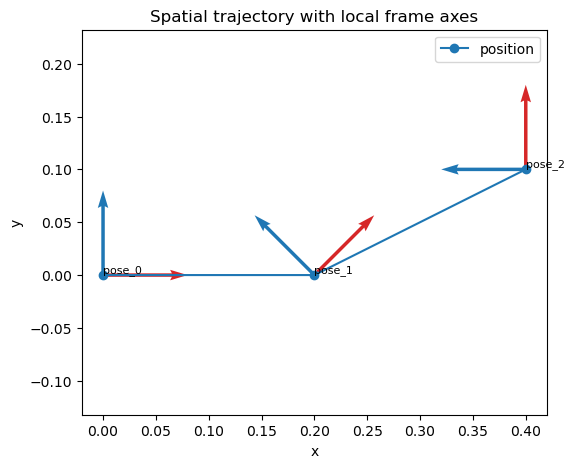

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

pos_ds = pos.unsafe_data
position = pos_ds['position']
x = position.sel(axis='x').to_numpy()
y = position.sel(axis='y').to_numpy()
ax.plot(x, y, marker='o', label='position')

quat = rot.unsafe_data['rotation']
yaw = 2.0 * np.arctan2(quat.sel(quat='z'), quat.sel(quat='w')).to_numpy()
axis_length = 0.08
for idx in [0, 1, 2]:
    c = float(np.cos(yaw[idx]))
    s = float(np.sin(yaw[idx]))
    ax.quiver(x[idx], y[idx], c, s, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:red')
    ax.quiver(x[idx], y[idx], -s, c, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:blue')
    ax.text(x[idx], y[idx], f'pose_{idx}', fontsize=8, ha='left', va='bottom')

ax.set(title='Spatial trajectory with local frame axes', xlabel='x', ylabel='y')
ax.axis('equal')
ax.legend(loc='best')


## Takeaways

- `Position`, `Rotation`, and `Pose` wrap AO semantics with spatial meaning.
- Representation conversion changes storage, not the underlying role structure.
- Rotation interpolation should use rotation-aware behavior where available.

**Exercise:** change the query times for `rot_mid` and compare them with `pos_mid`.
